### Prep Data

In [20]:
import pandas as pd

classification_df = pd.read_csv('data/diabetes_three_category.csv')

# show unique values for each column
for col in classification_df.columns:
    print(f"{col}: {classification_df[col].unique()}")

Diabetes_012: [0. 2. 1.]
HighBP: [1. 0.]
HighChol: [1. 0.]
CholCheck: [1. 0.]
BMI: [40. 25. 28. 27. 24. 30. 34. 26. 33. 21. 23. 22. 38. 32. 37. 31. 29. 20.
 35. 45. 39. 19. 47. 18. 36. 43. 55. 49. 42. 17. 16. 41. 44. 50. 59. 48.
 52. 46. 54. 57. 53. 14. 15. 51. 58. 63. 61. 56. 74. 62. 64. 66. 73. 85.
 60. 67. 65. 70. 82. 79. 92. 68. 72. 88. 96. 13. 81. 71. 75. 12. 77. 69.
 76. 87. 89. 84. 95. 98. 91. 86. 83. 80. 90. 78.]
Smoker: [1. 0.]
Stroke: [0. 1.]
HeartDiseaseorAttack: [0. 1.]
PhysActivity: [0. 1.]
Fruits: [0. 1.]
Veggies: [1. 0.]
HvyAlcoholConsump: [0. 1.]
AnyHealthcare: [1. 0.]
NoDocbcCost: [0. 1.]
GenHlth: [5. 3. 2. 4. 1.]
MentHlth: [18.  0. 30.  3.  5. 15. 10.  6. 20.  2. 25.  1.  4.  7.  8. 21. 14. 26.
 29. 16. 28. 11. 12. 24. 17. 13. 27. 19. 22.  9. 23.]
PhysHlth: [15.  0. 30.  2. 14. 28.  7. 20.  3. 10.  1.  5. 17.  4. 19.  6. 12. 25.
 27. 21. 22.  8. 29. 24.  9. 16. 18. 23. 13. 26. 11.]
DiffWalk: [1. 0.]
Sex: [0. 1.]
Age: [ 9.  7. 11. 10.  8. 13.  4.  6.  2. 12.  5.  1.  3

In [21]:
binary_df = pd.read_csv('data/diabetes_two_category.csv')
binary_df.head()
binary_df.columns
# move column to end
# binary_df['Diabetes_binary'] = binary_df.pop('Diabetes_binary')
# classification_df['Diabetes_012'] = classification_df.pop('Diabetes_012')

# rewrite with target at end
# classification_df.to_csv('data/diabetes_three_category.csv', index=False)
# binary_df.to_csv('data/diabetes_two_category.csv', index=False)




Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [22]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# prep data 
classification_df = classification_df.sample(frac=1, random_state=42).reset_index(drop=True)
binary_df = binary_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Standard scaling before PCA for classification_df
features_class = classification_df.loc[:, classification_df.columns != 'Diabetes_012']
target_class = classification_df['Diabetes_012']
scaler_class = StandardScaler()
features_class_scaled = scaler_class.fit_transform(features_class)
pca_class = PCA(n_components=10, random_state=42)
features_class_pca = pca_class.fit_transform(features_class_scaled)
classification_df_pca = pd.DataFrame(features_class_pca)
classification_df_pca['Diabetes_012'] = target_class.values

# Standard scaling before PCA for binary_df
features_bin = binary_df.loc[:, binary_df.columns != 'Diabetes_binary']
target_bin = binary_df['Diabetes_binary']
scaler_bin = StandardScaler()
features_bin_scaled = scaler_bin.fit_transform(features_bin)
pca_bin = PCA(n_components=10, random_state=42)
features_bin_pca = pca_bin.fit_transform(features_bin_scaled)
binary_df_pca = pd.DataFrame(features_bin_pca)
binary_df_pca['Diabetes_binary'] = target_bin.values

# set aside 10% of data for part B
bin_train, bin_test = train_test_split(binary_df_pca, test_size=0.1, random_state=42)
class_train, class_test = train_test_split(classification_df_pca, test_size=0.1, random_state=42)

# split into 4 sets
classification_sets = [df.reset_index(drop=True) for df in np.array_split(class_train, 4)]
binary_sets = [df.reset_index(drop=True) for df in np.array_split(bin_train, 4)]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

c_forest_df = classification_sets[1]
b_forest_df = binary_sets[1]

### Run multi-class forest classifier

In [23]:
from sklearn.ensemble import RandomForestClassifier
# random forest with full range of classifications
forest_class_accuracies = []
class_forest_min_samples_splits = [2, 10, 20, 50, 100]
for split in class_forest_min_samples_splits:
    accuracies_list = []
    for i, (train, test) in enumerate(kf.split(c_forest_df.loc[:, c_forest_df.columns != 'Diabetes_012'], c_forest_df['Diabetes_012'])):
        print(f"Fold {i+1}")
        print("TRAIN indices:", train)
        print("TEST indices:", test)

        X_forest_train = c_forest_df.loc[train, c_forest_df.columns != 'Diabetes_012']
        y_forest_train = c_forest_df.loc[train, 'Diabetes_012']

        X_forest_test = c_forest_df.loc[test, c_forest_df.columns != 'Diabetes_012']
        y_forest_test = c_forest_df.loc[test, 'Diabetes_012']

        rf_classifier = RandomForestClassifier(min_samples_split=split, random_state=42)
        rf_classifier.fit(X_forest_train, y_forest_train)
        scores = rf_classifier.score(X_forest_test, y_forest_test)
        print(f"Accuracy of splits = {split}: {scores}\n")
        accuracies_list.append(scores)
        
    forest_class_accuracies.append(accuracies_list)


Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    4     6    31 ... 57062 57065 57070]
Accuracy of splits = 2: 0.8434653118430273

Fold 2
TRAIN indices: [    2     3     4 ... 57075 57076 57077]
TEST indices: [    0     1     7 ... 57061 57063 57067]
Accuracy of splits = 2: 0.8481955150665732

Fold 3
TRAIN indices: [    0     1     2 ... 57071 57074 57077]
TEST indices: [    3     8    14 ... 57073 57075 57076]
Accuracy of splits = 2: 0.8423265592151367

Fold 4
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    5    15    18 ... 57058 57069 57071]
Accuracy of splits = 2: 0.8424879544459045

Fold 5
TRAIN indices: [    0     1     3 ... 57073 57075 57076]
TEST indices: [    2     9    10 ... 57060 57074 57077]


KeyboardInterrupt: 

### Run binary forest classifier

In [ ]:
# binary version of forest
forest_bin_accuracies = []
bin_forest_min_samples_splits = [2, 10, 20, 50, 100]
for split in bin_forest_min_samples_splits:
    accuracies_list = []
    for i, (train, test) in enumerate(kf.split(c_forest_df.loc[:, c_forest_df.columns != 'Diabetes_012'], c_forest_df['Diabetes_012'])):
        print(f"Fold {i+1}")
        print("TRAIN indices:", train)
        print("TEST indices:", test)

        X_forest_train = c_forest_df.loc[train, c_forest_df.columns != 'Diabetes_012']
        y_forest_train = c_forest_df.loc[train, 'Diabetes_012']

        X_forest_test = c_forest_df.loc[test, c_forest_df.columns != 'Diabetes_012']
        y_forest_test = c_forest_df.loc[test, 'Diabetes_012']

        rf_classifier = RandomForestClassifier(min_samples_split=split, random_state=42)
        rf_classifier.fit(X_forest_train, y_forest_train)
        scores = rf_classifier.score(X_forest_test, y_forest_test)
        print(f"Accuracy of splits = {split}: {scores}\n")
        accuracies_list.append(scores)
        
    forest_bin_accuracies.append(accuracies_list)

Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    4     6    31 ... 57062 57065 57070]
Accuracy of splits = 2: 0.8434653118430273

Fold 2
TRAIN indices: [    2     3     4 ... 57075 57076 57077]
TEST indices: [    0     1     7 ... 57061 57063 57067]
Accuracy of splits = 2: 0.8481955150665732

Fold 3
TRAIN indices: [    0     1     2 ... 57071 57074 57077]
TEST indices: [    3     8    14 ... 57073 57075 57076]
Accuracy of splits = 2: 0.8423265592151367

Fold 4
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    5    15    18 ... 57058 57069 57071]
Accuracy of splits = 2: 0.8424879544459045

Fold 5
TRAIN indices: [    0     1     3 ... 57073 57075 57076]
TEST indices: [    2     9    10 ... 57060 57074 57077]
Accuracy of splits = 2: 0.8487078405606658

Fold 1
TRAIN indices: [    0     1     2 ... 57075 57076 57077]
TEST indices: [    4     6    31 ... 57062 57065 57070]
Accuracy of splits = 10: 0.843552908199019

Fold 2
TRAIN ind

### Plot kfold validation of each 

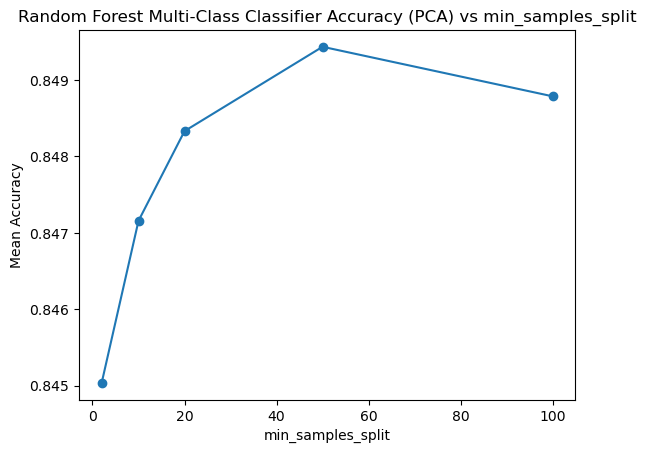

In [ ]:
import matplotlib.pyplot as plt

# process results and plot
forest_class_mean_accuracies = [np.mean(acc) for acc in forest_class_accuracies]

plt.plot(class_forest_min_samples_splits, forest_class_mean_accuracies, marker='o')
plt.title('Random Forest Multi-Class Classifier Accuracy (PCA) vs min_samples_split')
plt.xlabel('min_samples_split')
plt.ylabel('Mean Accuracy')
plt.show()

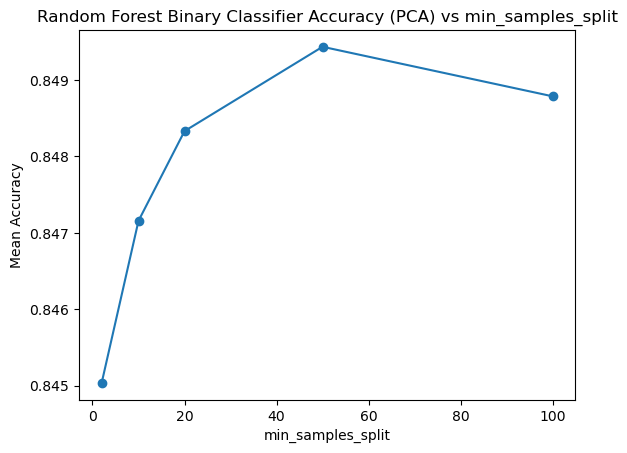

In [ ]:
# process results and plot
forest_bin_mean_accuracies = [np.mean(acc) for acc in forest_bin_accuracies]

plt.plot(bin_forest_min_samples_splits, forest_bin_mean_accuracies, marker='o')
plt.title('Random Forest Binary Classifier Accuracy (PCA) vs min_samples_split')
plt.xlabel('min_samples_split')
plt.ylabel('Mean Accuracy')
plt.show()

### Get final performance and runtime of best binary forest model

In [26]:
# prep data for final training
best_bin_rf_split = 50
best_bin_rf_classifier = RandomForestClassifier(min_samples_split=best_bin_rf_split, random_state=42)

In [27]:
# train and get runtime
best_bin_rf_classifier.fit(bin_train.loc[:, bin_train.columns != 'Diabetes_binary'], bin_train['Diabetes_binary'])

RandomForestClassifier(min_samples_split=50, random_state=42)

In [28]:
# training performance
best_bin_rf_classifier.score(bin_train.loc[:, bin_train.columns != 'Diabetes_binary'], bin_train['Diabetes_binary'])

0.8925286450120887

In [29]:
# testing performance
best_bin_rf_classifier.score(bin_test.loc[:, bin_test.columns != 'Diabetes_binary'], bin_test['Diabetes_binary'])

0.8610848312835068

### Get final performance and runtime of best class forest model

In [30]:
# prep data for final training
best_class_rf_split = 50
best_class_rf_classifier = RandomForestClassifier(min_samples_split=best_class_rf_split, random_state=42)

In [31]:
# train and get runtime
best_class_rf_classifier.fit(class_train.loc[:, class_train.columns != 'Diabetes_012'], class_train['Diabetes_012'])

RandomForestClassifier(min_samples_split=50, random_state=42)

In [32]:
# training performance
best_class_rf_classifier.score(class_train.loc[:, class_train.columns != 'Diabetes_012'], class_train['Diabetes_012'])

0.8774265040821332

In [33]:
# testing performance
best_class_rf_classifier.score(class_test.loc[:, class_test.columns != 'Diabetes_012'], class_test['Diabetes_012'])

0.8455928729107537